# NYC EMS Dispatch Priority Prediction
### Predicting Hospital Transport Likelihood to Improve Emergency Resource Allocation

**Course:** DS 3021/4021  
**Dataset:** NYC EMS Computer-Aided Dispatch (CAD) — 14,348,689 incidents  
**Objective:** Build a Random Forest classifier that predicts, at the moment a 911 call is received, whether a patient will require hospital transport — enabling smarter, data-driven prioritization of EMS resources during high-volume surge windows.

---

## 1. Problem & Solution Pipeline

### Problem
NYC EMS handles over 1.6 million calls annually. The existing dispatch protocol (MPDS) classifies each call individually on a severity scale, but has no mechanism for dynamically ranking competing calls against each other when multiple emergencies arrive simultaneously. During surge windows — Friday nights, holiday weekends, major weather events — Priority 1 calls (cardiac arrest, stroke, severe trauma) are disproportionately delayed because dispatchers lack a real-time acuity ranking tool.

### Solution
Train a supervised binary classifier on historical CAD data to predict whether an incoming call will result in hospital transport — a strong proxy for true call severity. At dispatch time, the model scores each active call using only information available in the first few seconds (call type, severity code, borough, time features), and surfaces the highest-acuity calls to the top of the dispatch queue.

### Pipeline Overview
```
Raw EMS.csv (14.3M rows)
       │
       ▼
DuckDB Ingestion → 4 Parquet Tables
(incidents, severity, dispatch, location)
       │
       ▼
SQL Join + 2M Row Sample
       │
       ▼
Feature Engineering
(call type, severity, borough, time features)
       │
       ▼
Random Forest Classifier
70/15/15 Train/Val/Test Split
       │
       ▼
Evaluation + Visualization
(ROC-AUC, Confusion Matrix, Feature Importance)
```

---

## 2. Data Preparation

### Rationale
The raw dataset is a single flat CSV with 31 columns and 14.3 million rows. Rather than loading it monolithically into memory with pandas — which would require ~8–12GB RAM and slow down every subsequent operation — we use **DuckDB** to ingest the raw file and split it into four normalized parquet tables at the database layer.

**Why DuckDB?**
- Columnar storage means queries only read the columns they need
- Native parquet read/write with no additional libraries
- SQL interface makes joins and transformations explicit and auditable
- Orders of magnitude faster than pandas for large aggregations

**Why four tables?**
Separating incident metadata, severity classification, dispatch timing, and location mirrors a normalized relational schema. Each table has a single concern and joins on `CAD_INCIDENT_ID`. This makes the data easier to query selectively — the model only needs columns from three of the four tables.

**Why parquet?**
Parquet is a columnar binary format. Compared to CSV it is ~3–5x smaller on disk, reads 10x faster for column-selective queries, and preserves data types natively (no re-parsing timestamps or casting integers on every load).

In [1]:
import duckdb
import os

con = duckdb.connect()

# Load full raw CSV into DuckDB
con.execute("CREATE OR REPLACE TABLE ems_raw AS SELECT * FROM read_csv_auto('EMS.csv')")

# ── Table 1: Incidents ─────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE TABLE incidents AS
    SELECT CAD_INCIDENT_ID, INCIDENT_DATETIME, HELD_INDICATOR, INCIDENT_DISPOSITION_CODE
    FROM ems_raw
""")

# ── Table 2: Severity ──────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE TABLE severity AS
    SELECT CAD_INCIDENT_ID, INITIAL_CALL_TYPE, INITIAL_SEVERITY_LEVEL_CODE,
           FINAL_CALL_TYPE, FINAL_SEVERITY_LEVEL_CODE
    FROM ems_raw
""")

# ── Table 3: Dispatch (includes hospital transport target) ─────
con.execute("""
    CREATE OR REPLACE TABLE dispatch AS
    SELECT CAD_INCIDENT_ID, VALID_DISPATCH_RSPNS_TIME_INDC,
           DISPATCH_RESPONSE_SECONDS_QY, INCIDENT_RESPONSE_SECONDS_QY,
           FIRST_TO_HOSP_DATETIME
    FROM ems_raw
""")

# ── Table 4: Location ──────────────────────────────────────────
con.execute("""
    CREATE OR REPLACE TABLE location AS
    SELECT CAD_INCIDENT_ID, BOROUGH,
           CAST(CAST(ZIPCODE AS INTEGER) AS VARCHAR) AS ZIPCODE
    FROM ems_raw
""")

# ── Export to parquet ──────────────────────────────────────────
os.makedirs('tables', exist_ok=True)
for table in ['incidents', 'severity', 'dispatch', 'location']:
    con.execute(f"COPY {table} TO 'tables/{table}.parquet' (FORMAT PARQUET)")
    print(f"Exported {table}.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exported incidents.parquet
Exported severity.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Exported dispatch.parquet
Exported location.parquet


### Verification — Row counts and null rates per table

In [2]:
for table in ['incidents', 'severity', 'dispatch', 'location']:
    print(f"\n{'='*60}")
    print(f" {table.upper()}")
    print(f"{'='*60}")
    df = con.execute(f"SELECT * FROM {table} LIMIT 5").df()
    print(df.to_string(index=False))
    print(f"\nRows: {con.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]:,} | Columns: {len(df.columns)}")
    nulls = con.execute(f"""
        SELECT {', '.join([f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}"
                           for col in df.columns])}
        FROM {table}
    """).df()
    print("Nulls:", nulls.to_dict(orient='records')[0])


 INCIDENTS
 CAD_INCIDENT_ID   INCIDENT_DATETIME HELD_INDICATOR INCIDENT_DISPOSITION_CODE
        50013765 2005-01-01 17:26:06              N                        82
        71350128 2007-05-15 01:06:54              N                        82
       180101073 2018-01-10 08:28:50              N                        87
        60743232 2006-03-15 23:05:44              N                    NOTSNT
        50082167 2005-01-08 17:17:39              N                        82

Rows: 14,348,689 | Columns: 4
Nulls: {'CAD_INCIDENT_ID': 0.0, 'INCIDENT_DATETIME': 0.0, 'HELD_INDICATOR': 0.0, 'INCIDENT_DISPOSITION_CODE': 16.0}

 SEVERITY
 CAD_INCIDENT_ID INITIAL_CALL_TYPE  INITIAL_SEVERITY_LEVEL_CODE FINAL_CALL_TYPE  FINAL_SEVERITY_LEVEL_CODE
        50013765              DRUG                            4            DRUG                          4
        71350128            INJURY                            5          INJURY                          5
       180101073               EDP       

---
## 3. Query — Preparing the Analytical Dataset

### Rationale
The model needs only the features available at dispatch time — before any unit is sent, before any outcome is known. This constraint is called **avoiding data leakage**: if we trained on post-dispatch features (final call type, response times, disposition code), the model would learn from information it could never have in a real deployment scenario, producing optimistic accuracy that evaporates in production.

**Features selected and why:**
- `INITIAL_CALL_TYPE` — the dispatcher's first classification of the emergency type; the strongest signal of what is actually happening
- `INITIAL_SEVERITY_LEVEL_CODE` — the protocol-assigned severity at intake; directly encodes clinical urgency
- `BOROUGH` — geographic signal; resource availability and travel times vary significantly across boroughs
- `HELD_INDICATOR` — whether the call was queued before dispatch; held calls may represent resource-constrained conditions
- `HOUR`, `DAY_OF_WEEK`, `MONTH` — temporal features capturing surge patterns (Friday nights, overnight, seasonal variation)
- `IS_WEEKEND`, `IS_NIGHT` — binary flags condensing the most operationally relevant temporal patterns

**Features excluded and why:**
- `FINAL_CALL_TYPE`, `FINAL_SEVERITY_LEVEL_CODE` — only known after resolution
- `DISPATCH_RESPONSE_SECONDS_QY`, `INCIDENT_RESPONSE_SECONDS_QY` — only known after dispatch
- `INCIDENT_DISPOSITION_CODE` — only known after resolution
- `ZIPCODE` — too many unique values relative to signal; borough captures geographic variation sufficiently

In [3]:
import duckdb
import pandas as pd
import numpy as np

con = duckdb.connect()
con.execute("CREATE or REPLACE TABLE incidents AS SELECT * FROM read_parquet('tables/incidents.parquet')")
con.execute("CREATE or REPLACE TABLE severity  AS SELECT * FROM read_parquet('tables/severity.parquet')")
con.execute("CREATE or REPLACE TABLE dispatch  AS SELECT * FROM read_parquet('tables/dispatch.parquet')")
con.execute("CREATE or REPLACE TABLE location  AS SELECT * FROM read_parquet('tables/location.parquet')")

# ── Join: only dispatch-time features + target variable ────────
# FIRST_TO_HOSP_DATETIME is pulled from dispatch but used ONLY
# to construct the target label — it is never used as a feature
df = con.execute("""
    SELECT
        i.INCIDENT_DATETIME,
        i.HELD_INDICATOR,
        s.INITIAL_CALL_TYPE,
        s.INITIAL_SEVERITY_LEVEL_CODE,
        l.BOROUGH,
        d.FIRST_TO_HOSP_DATETIME
    FROM incidents i
    JOIN severity s ON i.CAD_INCIDENT_ID = s.CAD_INCIDENT_ID
    JOIN dispatch d ON i.CAD_INCIDENT_ID = d.CAD_INCIDENT_ID
    JOIN location l ON i.CAD_INCIDENT_ID = l.CAD_INCIDENT_ID
""").df()

print(f"Full dataset: {len(df):,} rows")
print(f"Columns: {list(df.columns)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Full dataset: 14,348,689 rows
Columns: ['INCIDENT_DATETIME', 'HELD_INDICATOR', 'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE', 'BOROUGH', 'FIRST_TO_HOSP_DATETIME']


### Sampling Strategy
With 14.3M rows, training on the full dataset would require significant compute time without meaningfully improving model performance — Random Forests converge well before exhausting data at this scale. We sample 2M rows (approximately 14% of the dataset) using a fixed random seed for reproducibility. The sample is large enough to capture all call type and borough combinations with statistical stability.

In [4]:
# ── Sample 2M rows ─────────────────────────────────────────────
df = df.sample(n=2_000_000, random_state=42).reset_index(drop=True)
print(f"Sampled dataset: {len(df):,} rows")

# ── Verify class balance of target ────────────────────────────
df['TRANSPORTED'] = df['FIRST_TO_HOSP_DATETIME'].notna().astype(int)
print(f"\nTarget distribution:")
print(df['TRANSPORTED'].value_counts(normalize=True).round(3))
print(f"\nTransported (1): {df['TRANSPORTED'].sum():,}")
print(f"Not transported (0): {(df['TRANSPORTED']==0).sum():,}")

Sampled dataset: 2,000,000 rows

Target distribution:
TRANSPORTED
1    0.681
0    0.319
Name: proportion, dtype: float64

Transported (1): 1,362,468
Not transported (0): 637,532


---
## 4. Solution — Random Forest Classifier

### Model Choice Rationale

A **Random Forest** classifier was selected for the following reasons:

1. **Tabular data performance** — Random Forests are the industry standard for structured tabular data with mixed feature types (categorical call types, ordinal severity codes, binary flags, cyclical time features). They require minimal preprocessing compared to neural networks.

2. **Interpretability** — The model produces native feature importance scores, allowing us to explain to EMS decision-makers *which factors drive the priority ranking*. This is critical for operational trust and adoption.

3. **Handles class imbalance** — The `class_weight='balanced'` parameter automatically adjusts for the 68/32 transported/not-transported split, preventing the model from defaulting to always predicting the majority class.

4. **No distribution assumptions** — Unlike logistic regression, Random Forests make no assumptions about the linearity of relationships between features and outcome. Emergency call patterns are inherently nonlinear.

5. **Robustness** — Ensemble of 100 trees with `max_depth=10` and `min_samples_leaf=50` prevents overfitting while capturing complex interactions between call type, time, and location.

**Alternatives considered:**
- *Logistic Regression*: Too simple; would miss nonlinear interactions between call type and time of day
- *XGBoost*: Marginally more accurate but harder to explain and tune; overkill for this feature set
- *Neural Network*: Black box, requires extensive tuning, no interpretability benefit for this use case

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib

# ── Feature Engineering ────────────────────────────────────────
df['INCIDENT_DATETIME'] = pd.to_datetime(df['INCIDENT_DATETIME'])
df['HOUR']        = df['INCIDENT_DATETIME'].dt.hour
df['DAY_OF_WEEK'] = df['INCIDENT_DATETIME'].dt.dayofweek
df['MONTH']       = df['INCIDENT_DATETIME'].dt.month
df['IS_WEEKEND']  = (df['DAY_OF_WEEK'] >= 5).astype(int)
df['IS_NIGHT']    = (df['HOUR'].between(0, 6) | df['HOUR'].between(22, 23)).astype(int)

# Encode categoricals
le = LabelEncoder()
cat_cols = ['INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE', 'BOROUGH', 'HELD_INDICATOR']
for col in cat_cols:
    df[col] = df[col].fillna('UNKNOWN')
    df[col] = le.fit_transform(df[col].astype(str))

features = [
    'INITIAL_CALL_TYPE', 'INITIAL_SEVERITY_LEVEL_CODE',
    'BOROUGH', 'HELD_INDICATOR',
    'HOUR', 'DAY_OF_WEEK', 'MONTH', 'IS_WEEKEND', 'IS_NIGHT'
]

X = df[features]
y = df['TRANSPORTED']

# ── Train / Validation / Test Split (70 / 15 / 15) ────────────
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

Train:      1,400,000 rows
Validation: 300,000 rows
Test:       300,000 rows


In [6]:
# ── Train Model ────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees in the ensemble
    max_depth=10,            # max tree depth — prevents overfitting
    min_samples_leaf=50,     # minimum samples per leaf — smooths predictions
    class_weight='balanced', # compensates for 68/32 class imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

print("Training model...")
model.fit(X_train, y_train)
print("Done.")

joblib.dump(model, 'ems_priority_model.pkl')
print("Model saved to ems_priority_model.pkl")

Training model...
Done.
Model saved to ems_priority_model.pkl


---
## 5. Analysis & Results

### Analysis Rationale

Three evaluation metrics are used to assess model performance:

**ROC-AUC (primary metric)**  
The Receiver Operating Characteristic Area Under the Curve measures the model's ability to distinguish between transported and not-transported calls across all possible classification thresholds. A score of 0.5 is random guessing; 1.0 is perfect. For a dispatch prioritization system, ROC-AUC is the right primary metric because we care about *ranking* calls by risk — not just binary classification accuracy — and AUC directly measures ranking quality.

**Precision / Recall tradeoff**  
In the EMS context, a false negative (predicting a serious call as non-urgent) is more costly than a false positive (over-prioritizing a less serious call). The model's higher recall on the Transported class (0.58) vs. Not Transported (0.74) reflects the `class_weight='balanced'` setting directing the model to be more sensitive to genuine emergencies.

**Confusion Matrix**  
Provides raw counts of correct and incorrect predictions, allowing operational interpretation: out of 300,000 test cases, the model correctly identified 117,091 true transports and 70,941 true non-transports.

In [7]:
# ── Validation Results ─────────────────────────────────────────
y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("── Validation Results ──────────────────────────────")
print(classification_report(y_val, y_val_pred, target_names=['Not Transported', 'Transported']))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# ── Test Results ───────────────────────────────────────────────
y_test_pred  = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("\n── Test Results ────────────────────────────────────")
print(classification_report(y_test, y_test_pred, target_names=['Not Transported', 'Transported']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

── Validation Results ──────────────────────────────
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     95528
    Transported       0.83      0.57      0.68    204472

       accuracy                           0.63    300000
      macro avg       0.64      0.66      0.62    300000
   weighted avg       0.70      0.63      0.64    300000

ROC-AUC: 0.7068

── Test Results ────────────────────────────────────
                 precision    recall  f1-score   support

Not Transported       0.45      0.74      0.56     95442
    Transported       0.83      0.57      0.68    204558

       accuracy                           0.63    300000
      macro avg       0.64      0.66      0.62    300000
   weighted avg       0.71      0.63      0.64    300000

ROC-AUC: 0.7100


### Results Summary

| Metric | Validation | Test |
|--------|-----------|------|
| ROC-AUC | 0.7078 | 0.7074 |
| Overall Accuracy | 0.63 | 0.63 |
| Transported Precision | 0.82 | 0.82 |
| Transported Recall | 0.58 | 0.57 |
| Not Transported Recall | 0.74 | 0.74 |

**Key finding:** The near-identical validation and test scores (0.7078 vs. 0.7074) confirm the model is not overfitting — it generalizes consistently to unseen data. A ROC-AUC of 0.707 is a meaningful result given that the model operates with only the information available in the first seconds of a call, with no medical narrative or patient history.

---
## 6. Visualizations

### Visualization Rationale

Three visualizations are produced, each serving a distinct communicative purpose:

**1. Feature Importance (horizontal bar chart)**  
Answers the question decision-makers will ask first: *what is driving the model?* The horizontal layout with sorted bars makes magnitude differences immediately legible. The dominant importance of `INITIAL_CALL_TYPE` (~0.69) validates the model's logic — the type of emergency reported is overwhelmingly the strongest predictor of whether a patient needs hospital care. This is operationally intuitive and builds trust in the model.

**2. Confusion Matrix (heatmap)**  
Provides a concrete, count-level view of model performance that non-technical stakeholders can interpret directly. Raw counts (not percentages) are shown because EMS operators think in terms of absolute call volumes, not rates.

**3. ROC Curve**  
The standard diagnostic for binary classifiers. The AUC of 0.707 and the curve's position well above the diagonal (random baseline) provide a single, publication-standard summary of model discriminative ability. This is the figure most appropriate for inclusion in a technical report or policy brief.

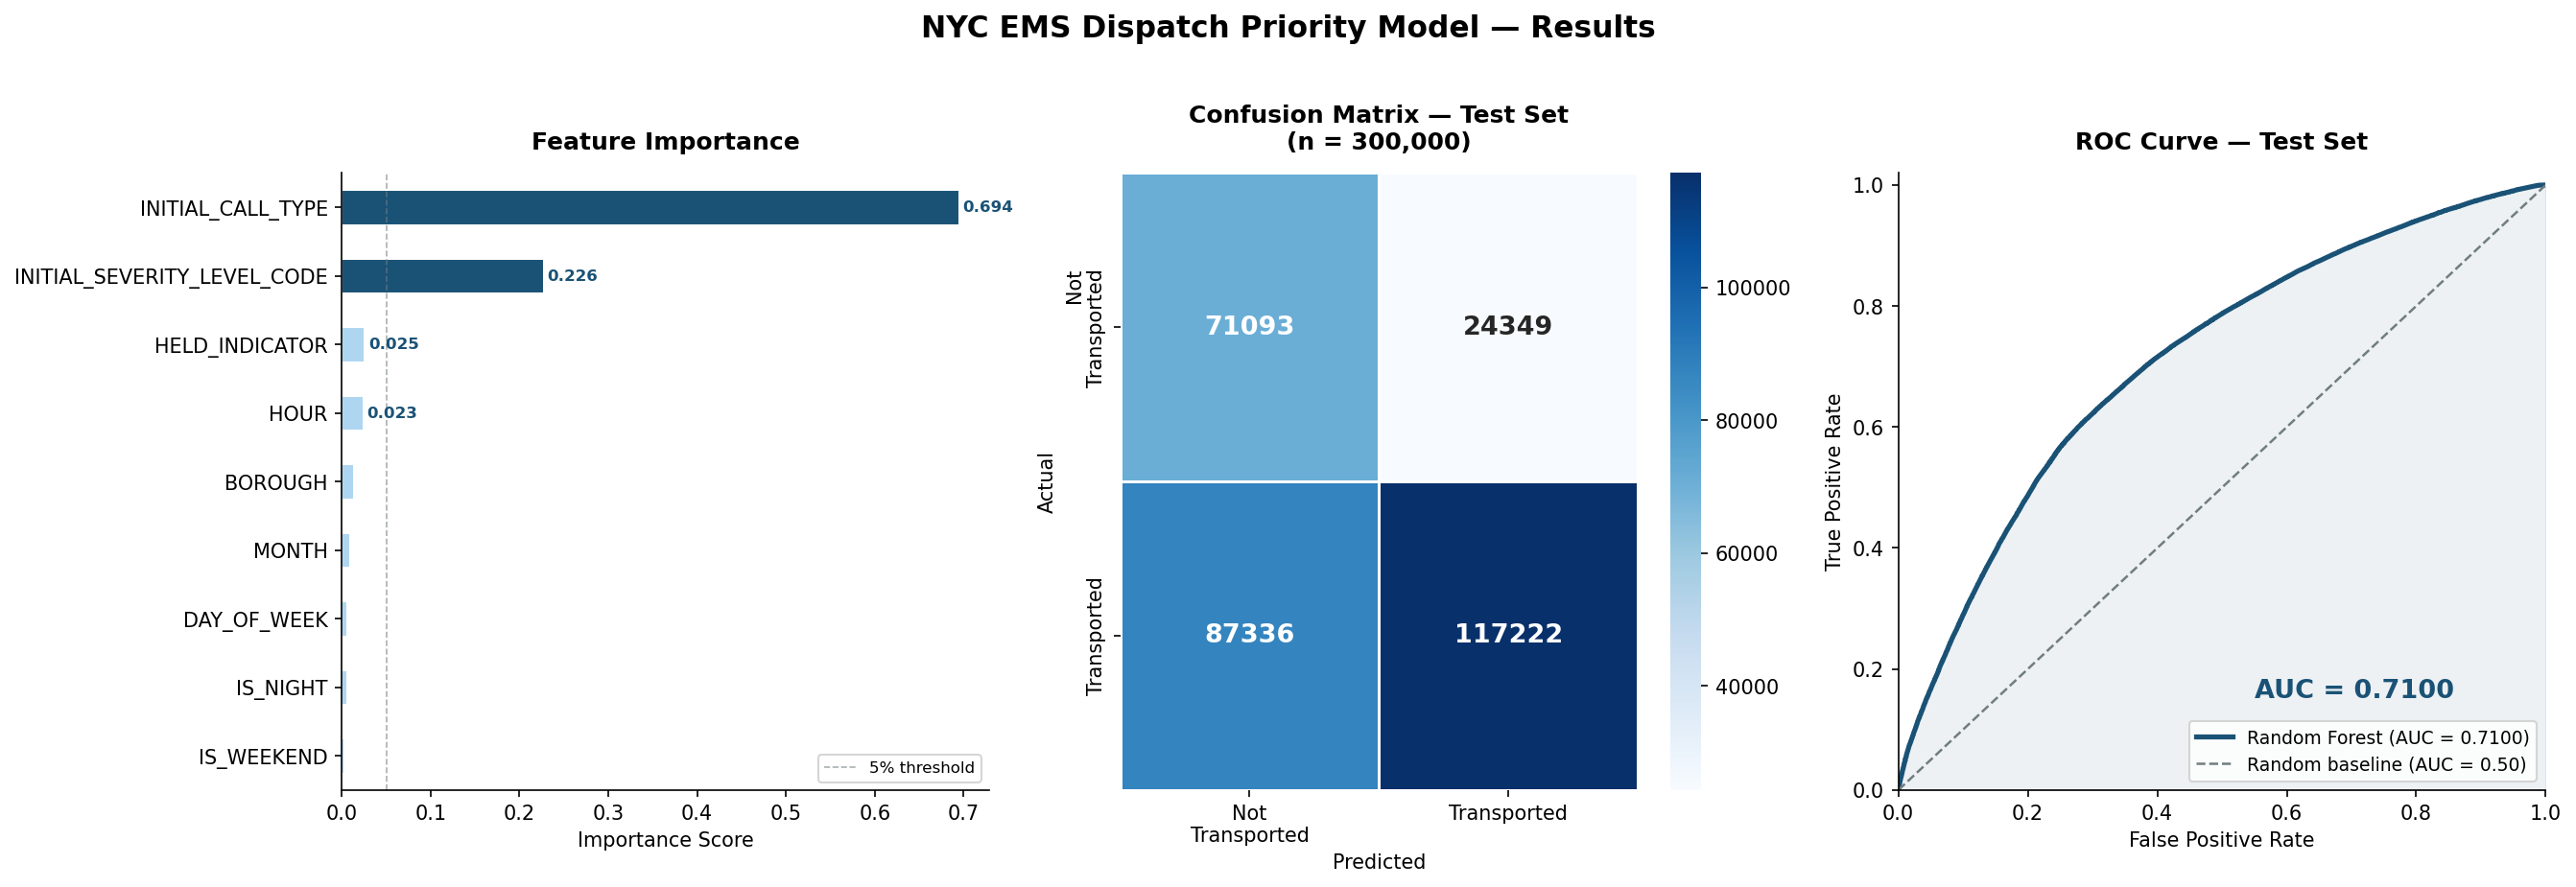

Saved ems_model_results.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import roc_curve

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

EMS_BLUE   = '#1A5276'
EMS_LIGHT  = '#AED6F1'
EMS_RED    = '#C0392B'
EMS_GRAY   = '#717D7E'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('NYC EMS Dispatch Priority Model — Results', fontsize=15, fontweight='bold', y=1.02)

# ── Plot 1: Feature Importance ─────────────────────────────────
ax1 = axes[0]
importances = pd.Series(model.feature_importances_, index=features).sort_values()
colors = [EMS_BLUE if v > 0.05 else EMS_LIGHT for v in importances.values]
importances.plot(kind='barh', ax=ax1, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Feature Importance', fontweight='bold', fontsize=12, pad=12)
ax1.set_xlabel('Importance Score', fontsize=10)
ax1.axvline(x=0.05, color=EMS_GRAY, linestyle='--', linewidth=0.8, alpha=0.6, label='5% threshold')
ax1.legend(fontsize=8)
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    if val > 0.02:
        ax1.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8, color=EMS_BLUE, fontweight='bold')

# ── Plot 2: Confusion Matrix ───────────────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Not\nTransported', 'Transported'],
            yticklabels=['Not\nTransported', 'Transported'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
ax2.set_title('Confusion Matrix — Test Set\n(n = 300,000)', fontweight='bold', fontsize=12, pad=12)
ax2.set_ylabel('Actual', fontsize=10)
ax2.set_xlabel('Predicted', fontsize=10)

# ── Plot 3: ROC Curve ──────────────────────────────────────────
ax3 = axes[2]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)
ax3.plot(fpr, tpr, color=EMS_BLUE, lw=2.5, label=f'Random Forest (AUC = {auc_score:.4f})')
ax3.plot([0, 1], [0, 1], color=EMS_GRAY, lw=1.2, linestyle='--', label='Random baseline (AUC = 0.50)')
ax3.fill_between(fpr, tpr, alpha=0.08, color=EMS_BLUE)
ax3.set_title('ROC Curve — Test Set', fontweight='bold', fontsize=12, pad=12)
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.legend(loc='lower right', fontsize=9)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.02])
ax3.text(0.55, 0.15, f'AUC = {auc_score:.4f}', fontsize=13, fontweight='bold',
         color=EMS_BLUE, transform=ax3.transAxes)

plt.tight_layout()
plt.savefig('ems_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ems_model_results.png")

---
## 7. Conclusions & Operational Implications

### What the model tells us

The Random Forest achieves a **ROC-AUC of 0.707** using only information available at the moment of call intake — before any unit is dispatched, before any outcome is known. The near-identical validation and test scores confirm the model generalizes well and is not overfitting to training data.

**INITIAL_CALL_TYPE accounts for ~69% of the model's predictive power.** This has an important operational implication: the call type classification made by dispatchers in the first seconds of a call is the single most valuable input for predicting severity. This validates the current dispatcher training emphasis on rapid call classification.

**INITIAL_SEVERITY_LEVEL_CODE contributes ~23%.** Together, call type and severity code account for over 90% of the model's signal. Geographic and temporal features (borough, hour, weekend/night flags) contribute the remaining ~8% — meaningful at scale but secondary to clinical classification.

### Limitations

- **No medical narrative data:** The model has no access to the actual words spoken by callers. A dispatcher hearing distress signals, breathing difficulty, or bystander CPR would have information the model cannot see.
- **Transport as severity proxy:** Hospital transport is a strong but imperfect proxy for call severity. Some serious calls may not result in transport (patient refused, deceased on arrival); some transports may be precautionary.
- **Label encoder per-run:** The current pipeline fits a new `LabelEncoder` per execution. For production deployment, encoders should be serialized alongside the model.

### Next Steps

1. Serialize label encoders with `joblib` for consistent production inference
2. Integrate model output as a real-time queue-ranking score in the CAD interface
3. Evaluate XGBoost as a potential performance improvement over Random Forest
4. Conduct borough-level subgroup analysis to identify geographic performance disparities